# 09 Feature-Space Similarity — OpenCV Telea Baseline

This notebook computes CLIP and DINOv2 feature-space similarities for the OpenCV Telea baseline on the 50-painting controlled subset.

The notebook compares:

1. clean image vs damaged image,
2. clean image vs OpenCV-restored image.

Feature similarity is computed for image-like spatial regions:

- full image,
- painting content region,
- mask bounding-box crop.

Sparse masked pixels are not used directly because CLIP and DINOv2 expect spatial image inputs rather than unordered pixel sets.

For cosine similarity, higher is better. Therefore:

`similarity_improvement = restored_similarity - damaged_similarity`

Positive improvement means the restored image is closer to the clean reference than the damaged input in that pretrained feature space.

CLIP and DINOv2 are used as diagnostic feature spaces, not as final truth measures of restoration quality.

In [1]:
from pathlib import Path
import sys
import yaml

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

CONFIG_PATH = PROJECT_ROOT / "config" / "experiment_50_config.yaml"

print("Project root:", PROJECT_ROOT)
print("Source directory:", SRC_DIR)
print("Source directory exists:", SRC_DIR.exists())
print("Config path:", CONFIG_PATH)
print("Config exists:", CONFIG_PATH.exists())

if not SRC_DIR.exists():
    raise FileNotFoundError(f"Source directory not found: {SRC_DIR}")

if not CONFIG_PATH.exists():
    raise FileNotFoundError(f"Experiment config not found: {CONFIG_PATH}")

Project root: D:\Masters\FH\Thesis\painting-restoration-eval
Source directory: D:\Masters\FH\Thesis\painting-restoration-eval\src
Source directory exists: True
Config path: D:\Masters\FH\Thesis\painting-restoration-eval\config\experiment_50_config.yaml
Config exists: True


In [2]:
import pandas as pd
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from restoration_eval.metrics_feature_similarity import (
    DEFAULT_CLIP_MODEL_NAME,
    DEFAULT_DINOV2_MODEL_NAME,
    DEFAULT_CROP_RESIZE,
    DEFAULT_MASK_BBOX_MARGIN,
    get_device,
    load_clip_model_and_processor,
    load_dinov2_model,
    compute_feature_similarity_for_restorations,
    validate_feature_similarity_metrics,
    summarize_feature_similarity_metrics,
    rank_feature_similarity_cases,
)

with CONFIG_PATH.open("r", encoding="utf-8") as f:
    config = yaml.safe_load(f)

paths_cfg = config.get("paths", {})
preprocessing_cfg = config.get("preprocessing", {})

processed_metadata_path = PROJECT_ROOT / paths_cfg["processed_metadata_dir"] / "metadata_processed_clean.csv"
restored_metadata_path = PROJECT_ROOT / paths_cfg["processed_metadata_dir"] / "metadata_restored_opencv_telea.csv"

metrics_dir = PROJECT_ROOT / paths_cfg["metrics_dir"]
metrics_dir.mkdir(parents=True, exist_ok=True)

feature_metrics_path = metrics_dir / "feature_similarity_opencv_telea_50.csv"

summary_by_region_path = metrics_dir / "feature_similarity_summary_by_region_opencv_telea_50.csv"
summary_by_mask_type_path = metrics_dir / "feature_similarity_summary_by_mask_type_opencv_telea_50.csv"
summary_by_category_path = metrics_dir / "feature_similarity_summary_by_category_opencv_telea_50.csv"
summary_by_region_mask_type_path = metrics_dir / "feature_similarity_summary_by_region_mask_type_opencv_telea_50.csv"
summary_by_region_category_path = metrics_dir / "feature_similarity_summary_by_region_category_opencv_telea_50.csv"

clip_strongest_cases_path = metrics_dir / "clip_strongest_mask_bbox_cases_opencv_telea_50.csv"
clip_weakest_cases_path = metrics_dir / "clip_weakest_mask_bbox_cases_opencv_telea_50.csv"
dinov2_strongest_cases_path = metrics_dir / "dinov2_strongest_mask_bbox_cases_opencv_telea_50.csv"
dinov2_weakest_cases_path = metrics_dir / "dinov2_weakest_mask_bbox_cases_opencv_telea_50.csv"

feature_classical_lpips_comparison_path = metrics_dir / "feature_classical_lpips_comparison_opencv_telea_50.csv"
feature_metric_disagreement_path = metrics_dir / "feature_metric_disagreement_cases_opencv_telea_50.csv"

target_size = (
    preprocessing_cfg.get("output_size")
    or preprocessing_cfg.get("target_size")
    or config.get("experiment", {}).get("image_size")
    or 768
)

clip_model_name = DEFAULT_CLIP_MODEL_NAME
dinov2_model_name = DEFAULT_DINOV2_MODEL_NAME
feature_resize = DEFAULT_CROP_RESIZE
mask_bbox_margin = DEFAULT_MASK_BBOX_MARGIN

print("Processed metadata path:", processed_metadata_path)
print("Processed metadata exists:", processed_metadata_path.exists())
print("Restored metadata path:", restored_metadata_path)
print("Restored metadata exists:", restored_metadata_path.exists())
print("Feature metrics output:", feature_metrics_path)
print("Target size:", target_size)
print("CLIP model:", clip_model_name)
print("DINOv2 model:", dinov2_model_name)
print("Feature resize:", feature_resize)
print("Mask bbox margin:", mask_bbox_margin)

if not processed_metadata_path.exists():
    raise FileNotFoundError(
        f"Processed metadata not found: {processed_metadata_path}. "
        "Run Notebook 02 first."
    )

if not restored_metadata_path.exists():
    raise FileNotFoundError(
        f"OpenCV restoration metadata not found: {restored_metadata_path}. "
        "Run Notebook 05 first."
    )

processed_metadata_df = pd.read_csv(processed_metadata_path)
restored_metadata_df = pd.read_csv(restored_metadata_path)

print("\nProcessed metadata shape:", processed_metadata_df.shape)
print("Restored metadata shape:", restored_metadata_df.shape)

display(processed_metadata_df.head())
display(restored_metadata_df.head())

Processed metadata path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_processed_clean.csv
Processed metadata exists: True
Restored metadata path: D:\Masters\FH\Thesis\painting-restoration-eval\data\processed\metadata\metadata_restored_opencv_telea.csv
Restored metadata exists: True
Feature metrics output: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_opencv_telea_50.csv
Target size: 768
CLIP model: openai/clip-vit-base-patch32
DINOv2 model: dinov2_vits14
Feature resize: 224
Mask bbox margin: 32

Processed metadata shape: (50, 43)
Restored metadata shape: (250, 20)


,painting_id,category,title,artist,date,style_or_period,medium,source,source_url,license,...,padding_color_b,content_x_min,content_y_min,content_x_max,content_y_max,content_width,content_height,preprocessing_method,content_area_pixels,content_area_percentage
0,p001,portrait_figure,Juan de Pareja,Diego Velázquez,1650,Baroque,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,20,52,0,715,768,663,768,aspect_ratio_resize_median_rgb_pad,509184,86.33
1,p002,portrait_figure,Madame X (Madame Pierre Gautreau),John Singer Sargent,1883-84,19th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,35,159,0,608,768,449,768,aspect_ratio_resize_median_rgb_pad,344832,58.46
2,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,Marie-Denise Villers,1801,Neoclassical / early 19th century,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,39,77,0,691,768,614,768,aspect_ratio_resize_median_rgb_pad,471552,79.95
3,p004,portrait_figure,Madame Georges Charpentier and Her Children,Pierre-Auguste Renoir,1878,Impressionism,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,62,0,71,768,696,768,625,aspect_ratio_resize_median_rgb_pad,480000,81.38
4,p005,portrait_figure,Self-Portrait with Two Pupils,Adélaïde Labille-Guiard,1785,18th century portraiture,Oil on canvas,The Metropolitan Museum of Art,https://www.metmuseum.org/art/collection/searc...,Public Domain / Open Access,...,34,99,0,668,768,569,768,aspect_ratio_resize_median_rgb_pad,436992,74.09


,case_id,painting_id,mask_id,mask_type,model_name,algorithm,inpaint_radius,clean_filename,clean_path,mask_filename,mask_path,damaged_filename,damaged_path,restored_filename,restored_path,damaged_area_pixels,damaged_area_percentage_content,damaged_area_percentage_full,status,issue
0,p001_loss_large,p001,p001_loss_large,loss_large,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,67242,13.2058,11.4003,ok,NaN
1,p001_loss_small,p001,p001_loss_small,loss_small,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,24198,4.7523,4.1026,ok,NaN
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,44392,8.7183,7.5263,ok,NaN
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,8012,1.5735,1.3584,ok,NaN
4,p001_zero_control,p001,p001_zero_control,zero_control,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_damaged.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_restored_opencv_telea.png,D:\Masters\FH\Thesis\painting-restoration-eval...,0,0.0000,0.0000,ok,NaN


In [3]:
# Merge OpenCV restoration metadata with processed painting metadata

metadata_columns_to_add = [
    "painting_id",
    "category",
    "title",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
    "content_width",
    "content_height",
]

missing_processed_columns = [
    col for col in metadata_columns_to_add
    if col not in processed_metadata_df.columns
]

if missing_processed_columns:
    raise ValueError(
        f"Processed metadata is missing required columns for feature evaluation: "
        f"{missing_processed_columns}"
    )

processed_subset_df = processed_metadata_df[metadata_columns_to_add].copy()

feature_input_df = restored_metadata_df.merge(
    processed_subset_df,
    on="painting_id",
    how="left",
    validate="many_to_one",
)

print("Feature input shape:", feature_input_df.shape)

required_feature_input_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_id",
    "mask_type",
    "model_name",
    "clean_path",
    "damaged_path",
    "restored_path",
    "mask_path",
    "content_x_min",
    "content_y_min",
    "content_x_max",
    "content_y_max",
]

missing_feature_input_columns = [
    col for col in required_feature_input_columns
    if col not in feature_input_df.columns
]

print("\nRequired-column check:")
if missing_feature_input_columns:
    print("Missing columns:", missing_feature_input_columns)
else:
    print("All required feature input columns are present.")

print("\nRow counts:")
print("Restored metadata rows:", len(restored_metadata_df))
print("Feature input rows:", len(feature_input_df))

print("\nMask type counts:")
display(feature_input_df["mask_type"].value_counts().sort_index())

print("\nCategory counts:")
display(feature_input_df["category"].value_counts().sort_index())

print("\nRestoration status counts:")
display(feature_input_df["status"].value_counts(dropna=False))

print("\nIssue counts:")
display(feature_input_df["issue"].fillna("").replace("", "ok").value_counts())

if missing_feature_input_columns:
    raise ValueError("Feature input metadata is missing required columns.")

if len(feature_input_df) != 250:
    raise ValueError(f"Expected 250 OpenCV restoration rows, found {len(feature_input_df)}.")

if feature_input_df["case_id"].duplicated().any():
    duplicate_cases = feature_input_df.loc[
        feature_input_df["case_id"].duplicated(),
        "case_id",
    ].tolist()
    raise ValueError(f"Duplicate case IDs found: {duplicate_cases[:10]}")

if feature_input_df["category"].isna().any():
    missing_category_rows = feature_input_df[feature_input_df["category"].isna()]
    display(missing_category_rows[["case_id", "painting_id", "mask_type"]])
    raise ValueError("Some feature rows are missing category values.")

if (feature_input_df["status"] != "ok").any():
    failed_rows = feature_input_df[feature_input_df["status"] != "ok"]
    display(failed_rows)
    raise ValueError("Some OpenCV restoration rows have non-ok status.")

print("\nFeature-similarity input metadata gate passed.")
display(feature_input_df.head())

Feature input shape: (250, 28)

Required-column check:
All required feature input columns are present.

Row counts:
Restored metadata rows: 250
Feature input rows: 250

Mask type counts:


mask_type
loss_large      50
loss_small      50
mixed_damage    50
scratch_thin    50
zero_control    50
Name: count, dtype: int64


Category counts:


category
abstraction_surrealism     50
architecture_structured    50
high_texture_brushwork     50
landscape_natural          50
portrait_figure            50
Name: count, dtype: int64


Restoration status counts:


status
ok    250
Name: count, dtype: int64


Issue counts:


issue
ok    250
Name: count, dtype: int64


Feature-similarity input metadata gate passed.


,case_id,painting_id,mask_id,mask_type,model_name,algorithm,inpaint_radius,clean_filename,clean_path,mask_filename,...,status,issue,category,title,content_x_min,content_y_min,content_x_max,content_y_max,content_width,content_height
0,p001_loss_large,p001,p001_loss_large,loss_large,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_large_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768
1,p001_loss_small,p001,p001_loss_small,loss_small,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_loss_small_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768
2,p001_mixed_damage,p001,p001_mixed_damage,mixed_damage,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_mixed_damage_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768
3,p001_scratch_thin,p001,p001_scratch_thin,scratch_thin,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_scratch_thin_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768
4,p001_zero_control,p001,p001_zero_control,zero_control,opencv_telea,cv2.INPAINT_TELEA,3,p001_clean.png,D:\Masters\FH\Thesis\painting-restoration-eval...,p001_zero_control_mask.png,...,ok,NaN,portrait_figure,Juan de Pareja,52,0,715,768,663,768


In [4]:
# Load CLIP and DINOv2 feature models

device = get_device(prefer_cuda=True)

print("Selected device:", device)

print("\nLoading CLIP model...")
clip_model, clip_processor = load_clip_model_and_processor(
    model_name=clip_model_name,
    device=device,
)
print("CLIP model loaded:", clip_model_name)

print("\nLoading DINOv2 model...")
dinov2_model = load_dinov2_model(
    model_name=dinov2_model_name,
    device=device,
)
print("DINOv2 model loaded:", dinov2_model_name)

print("\nFeature models ready.")
print("Device:", device)
print("CLIP:", clip_model_name)
print("DINOv2:", dinov2_model_name)

print("CLIP model type:", type(clip_model))
print("DINOv2 model type:", type(dinov2_model))

Selected device: cuda

Loading CLIP model...


D:\Masters\FH\Thesis\painting-restoration-eval\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 398/398 [00:00<00:00, 4044.53it/s]


CLIP model loaded: openai/clip-vit-base-patch32

Loading DINOv2 model...


C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
C:\Users\rahul/.cache\torch\hub\facebookresearch_dinov2_main\dinov2\layers\block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


DINOv2 model loaded: dinov2_vits14

Feature models ready.
Device: cuda
CLIP: openai/clip-vit-base-patch32
DINOv2: dinov2_vits14
CLIP model type: <class 'transformers.models.clip.modeling_clip.CLIPModel'>
DINOv2 model type: <class 'dinov2.models.vision_transformer.DinoVisionTransformer'>


In [5]:
# One-painting feature-similarity test

test_painting_id = feature_input_df["painting_id"].sort_values().iloc[0]

test_feature_input_df = (
    feature_input_df[feature_input_df["painting_id"] == test_painting_id]
    .copy()
    .sort_values("mask_type")
    .reset_index(drop=True)
)

print("Test painting:", test_painting_id)
print("Test rows:", len(test_feature_input_df))
display(
    test_feature_input_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "clean_path",
            "damaged_path",
            "restored_path",
            "mask_path",
        ]
    ]
)

test_feature_metrics_df = compute_feature_similarity_for_restorations(
    restoration_metadata=test_feature_input_df,
    clip_model=clip_model,
    clip_processor=clip_processor,
    dinov2_model=dinov2_model,
    device=device,
    clip_model_name=clip_model_name,
    dinov2_model_name=dinov2_model_name,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    feature_resize=feature_resize,
    progress_every=1,
)

print("\nTest feature metrics shape:", test_feature_metrics_df.shape)

display(
    test_feature_metrics_df[
        [
            "case_id",
            "mask_type",
            "evaluation_region",
            "clip_damaged_similarity",
            "clip_restored_similarity",
            "clip_similarity_improvement",
            "dinov2_damaged_similarity",
            "dinov2_restored_similarity",
            "dinov2_similarity_improvement",
            "status",
            "issue",
        ]
    ]
)

Test painting: p001
Test rows: 5


,case_id,painting_id,category,title,mask_type,clean_path,damaged_path,restored_path,mask_path
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
1,p001_loss_small,p001,portrait_figure,Juan de Pareja,loss_small,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
2,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,mixed_damage,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
3,p001_scratch_thin,p001,portrait_figure,Juan de Pareja,scratch_thin,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...
4,p001_zero_control,p001,portrait_figure,Juan de Pareja,zero_control,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...,D:\Masters\FH\Thesis\painting-restoration-eval...


Starting feature-similarity computation for 5 restoration cases...
Expected feature metric rows: 14
Device: cuda
CLIP model: openai/clip-vit-base-patch32
DINOv2 model: dinov2_vits14
Processed 1/5 restoration cases...
Processed 2/5 restoration cases...
Processed 3/5 restoration cases...
Processed 4/5 restoration cases...
Processed 5/5 restoration cases...
Feature-similarity computation finished.

Test feature metrics shape: (14, 28)


,case_id,mask_type,evaluation_region,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,status,issue
0,p001_loss_large,loss_large,full_image,0.932040,0.967289,0.035249,0.796219,0.938681,0.142461,ok,
1,p001_loss_large,loss_large,content_region,0.916990,0.964814,0.047824,0.790295,0.920064,0.129769,ok,
2,p001_loss_large,loss_large,mask_bbox_crop,0.810900,0.808008,-0.002892,0.706465,0.748291,0.041827,ok,
3,p001_loss_small,loss_small,full_image,0.914921,0.999334,0.084412,0.935493,0.998409,0.062916,ok,
4,p001_loss_small,loss_small,content_region,0.920872,0.999257,0.078385,0.932966,0.998013,0.065047,ok,
5,p001_loss_small,loss_small,mask_bbox_crop,0.910694,0.999298,0.088604,0.948942,0.997888,0.048946,ok,
6,p001_mixed_damage,mixed_damage,full_image,0.895807,0.994364,0.098557,0.795198,0.974854,0.179656,ok,
7,p001_mixed_damage,mixed_damage,content_region,0.904811,0.992217,0.087406,0.794133,0.974776,0.180643,ok,
8,p001_mixed_damage,mixed_damage,mask_bbox_crop,0.895807,0.994364,0.098557,0.795198,0.974854,0.179656,ok,
9,p001_scratch_thin,scratch_thin,full_image,0.857966,0.999632,0.141666,0.924942,0.998968,0.074026,ok,


In [6]:
# Inspect one-painting feature-similarity sanity

print("Status counts:")
display(test_feature_metrics_df["status"].value_counts(dropna=False))

print("\nEvaluation region counts:")
display(test_feature_metrics_df["evaluation_region"].value_counts().sort_index())

print("\nZero-control rows:")
zero_test_df = test_feature_metrics_df[
    test_feature_metrics_df["mask_type"] == "zero_control"
].copy()

display(
    zero_test_df[
        [
            "case_id",
            "evaluation_region",
            "clip_damaged_similarity",
            "clip_restored_similarity",
            "clip_similarity_improvement",
            "dinov2_damaged_similarity",
            "dinov2_restored_similarity",
            "dinov2_similarity_improvement",
        ]
    ]
)

print("\nNon-zero mask-bbox rows:")
nonzero_mask_bbox_test_df = test_feature_metrics_df[
    (test_feature_metrics_df["mask_type"] != "zero_control")
    & (test_feature_metrics_df["evaluation_region"] == "mask_bbox_crop")
].copy()

display(
    nonzero_mask_bbox_test_df[
        [
            "case_id",
            "mask_type",
            "clip_damaged_similarity",
            "clip_restored_similarity",
            "clip_similarity_improvement",
            "dinov2_damaged_similarity",
            "dinov2_restored_similarity",
            "dinov2_similarity_improvement",
        ]
    ]
)

print("\nFeature similarity value ranges:")
display(
    test_feature_metrics_df[
        [
            "clip_damaged_similarity",
            "clip_restored_similarity",
            "clip_similarity_improvement",
            "dinov2_damaged_similarity",
            "dinov2_restored_similarity",
            "dinov2_similarity_improvement",
        ]
    ].describe().round(5)
)

zero_max_abs_improvement = zero_test_df[
    [
        "clip_similarity_improvement",
        "dinov2_similarity_improvement",
    ]
].abs().max().max()

print("\nZero-control maximum absolute feature-similarity improvement:", zero_max_abs_improvement)

if zero_max_abs_improvement > 1e-5:
    raise ValueError(
        "Zero-control feature similarity improvement is unexpectedly non-zero."
    )

if (test_feature_metrics_df["status"] != "ok").any():
    display(test_feature_metrics_df[test_feature_metrics_df["status"] != "ok"])
    raise ValueError("One-painting feature-similarity test produced non-ok rows.")

print("\nOne-painting feature-similarity sanity checks passed.")

Status counts:


status
ok    14
Name: count, dtype: int64


Evaluation region counts:


evaluation_region
content_region    5
full_image        5
mask_bbox_crop    4
Name: count, dtype: int64


Zero-control rows:


...


Non-zero mask-bbox rows:


,case_id,mask_type,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
2,p001_loss_large,loss_large,0.810900,0.808008,-0.002892,0.706465,0.748291,0.041827
5,p001_loss_small,loss_small,0.910694,0.999298,0.088604,0.948942,0.997888,0.048946
8,p001_mixed_damage,mixed_damage,0.895807,0.994364,0.098557,0.795198,0.974854,0.179656
11,p001_scratch_thin,scratch_thin,0.857966,0.999632,0.141666,0.924942,0.998968,0.074026



Feature similarity value ranges:


,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
count,14.00000,14.00000,14.00000,14.00000,14.00000,14.00000
mean,0.90164,0.97984,0.07820,0.87536,0.96590,0.09054
std,0.05735,0.05084,0.05845,0.09241,0.06745,0.06245
min,0.80420,0.80801,-0.00289,0.70646,0.74829,0.00000
25%,0.86743,0.99275,0.03839,0.79520,0.97480,0.05244
50%,0.90775,0.99928,0.08591,0.91757,0.99795,0.07403
75%,0.91990,0.99961,0.09856,0.93486,0.99893,0.13929
max,1.00000,1.00000,0.19533,1.00000,1.00000,0.18064



Zero-control maximum absolute feature-similarity improvement: 0.0

One-painting feature-similarity sanity checks passed.


In [8]:
# Compute feature-similarity metrics for all OpenCV restoration cases

feature_metrics_df = compute_feature_similarity_for_restorations(
    restoration_metadata=feature_input_df,
    clip_model=clip_model,
    clip_processor=clip_processor,
    dinov2_model=dinov2_model,
    device=device,
    clip_model_name=clip_model_name,
    dinov2_model_name=dinov2_model_name,
    target_size=target_size,
    mask_bbox_margin=mask_bbox_margin,
    feature_resize=feature_resize,
    progress_every=50,
)

print("Feature-similarity metric computation complete.")
print("Rows:", len(feature_metrics_df))
print("Expected rows: 700")

print("\nRows by evaluation region:")
display(feature_metrics_df["evaluation_region"].value_counts().sort_index())

print("\nRows by mask type:")
display(feature_metrics_df["mask_type"].value_counts().sort_index())

print("\nStatus counts:")
display(feature_metrics_df["status"].value_counts(dropna=False))

print("\nIssue counts:")
display(feature_metrics_df["issue"].fillna("").replace("", "ok").value_counts())

display(feature_metrics_df.head())

Starting feature-similarity computation for 250 restoration cases...
Expected feature metric rows: 700
Device: cuda
CLIP model: openai/clip-vit-base-patch32
DINOv2 model: dinov2_vits14
Processed 1/250 restoration cases...
Processed 50/250 restoration cases...
Processed 100/250 restoration cases...
Processed 150/250 restoration cases...
Processed 200/250 restoration cases...
Processed 250/250 restoration cases...
Feature-similarity computation finished.
Feature-similarity metric computation complete.
Rows: 700
Expected rows: 700

Rows by evaluation region:


evaluation_region
content_region    250
full_image        250
mask_bbox_crop    200
Name: count, dtype: int64


Rows by mask type:


mask_type
loss_large      150
loss_small      150
mixed_damage    150
scratch_thin    150
zero_control    100
Name: count, dtype: int64


Status counts:


status
ok    700
Name: count, dtype: int64


Issue counts:


issue
ok    700
Name: count, dtype: int64

,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,clip_model_name,dinov2_model_name,feature_resize,device,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,full_image,589824,0,...,0.035249,0.796219,0.938681,0.142461,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,content_region,509184,52,...,0.047824,0.790295,0.920064,0.129769,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,mask_bbox_crop,178929,197,...,-0.002892,0.706465,0.748291,0.041827,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,
3,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,full_image,589824,0,...,0.084412,0.935493,0.998409,0.062916,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,
4,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,content_region,509184,52,...,0.078385,0.932966,0.998013,0.065047,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,


In [9]:
# Save full feature-similarity metrics

feature_metrics_df.to_csv(feature_metrics_path, index=False)

print("Feature-similarity metrics saved:")
print(feature_metrics_path)
print("Saved file exists:", feature_metrics_path.exists())
print("Rows saved:", len(feature_metrics_df))
print("Columns:", len(feature_metrics_df.columns))

reloaded_feature_metrics_df = pd.read_csv(feature_metrics_path)

print("\nReloaded shape:", reloaded_feature_metrics_df.shape)
display(reloaded_feature_metrics_df.head())

Feature-similarity metrics saved:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_opencv_telea_50.csv
Saved file exists: True
Rows saved: 700
Columns: 28

Reloaded shape: (700, 28)


,case_id,painting_id,category,title,mask_id,mask_type,model_name,evaluation_region,region_pixel_count,region_x_min,...,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement,clip_model_name,dinov2_model_name,feature_resize,device,status,issue
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,full_image,589824,0,...,0.035249,0.796219,0.938681,0.142461,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,NaN
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,content_region,509184,52,...,0.047824,0.790295,0.920064,0.129769,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,NaN
2,p001_loss_large,p001,portrait_figure,Juan de Pareja,p001_loss_large,loss_large,opencv_telea,mask_bbox_crop,178929,197,...,-0.002892,0.706465,0.748291,0.041827,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,NaN
3,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,full_image,589824,0,...,0.084412,0.935493,0.998409,0.062916,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,NaN
4,p001_loss_small,p001,portrait_figure,Juan de Pareja,p001_loss_small,loss_small,opencv_telea,content_region,509184,52,...,0.078385,0.932966,0.998013,0.065047,openai/clip-vit-base-patch32,dinov2_vits14,224,cuda,ok,NaN


In [10]:
# Validate feature-similarity metric output

feature_validation_df = validate_feature_similarity_metrics(
    feature_df=feature_metrics_df,
    expected_rows=700,
)

display(feature_validation_df)

if not feature_validation_df["passed"].all():
    raise ValueError("Feature-similarity metrics validation failed.")

print("Feature-similarity metrics validation passed.")

,check,passed,detail
0,required_columns,True,All required columns present.
1,row_count,True,"Expected 700, found 700."
2,status_ok,True,Rows with non-ok status: 0.
3,region_counts,True,"{'full_image': 250, 'content_region': 250, 'ma..."


Feature-similarity metrics validation passed.


In [11]:
# Feature-similarity sanity checks

ok_feature_df = feature_metrics_df[feature_metrics_df["status"] == "ok"].copy()

zero_control_feature_df = ok_feature_df[
    ok_feature_df["mask_type"] == "zero_control"
].copy()

nonzero_feature_df = ok_feature_df[
    ok_feature_df["mask_type"] != "zero_control"
].copy()

mask_bbox_feature_df = ok_feature_df[
    ok_feature_df["evaluation_region"] == "mask_bbox_crop"
].copy()

print("Zero-control rows:", len(zero_control_feature_df))
print("Non-zero rows:", len(nonzero_feature_df))
print("Mask-bbox crop rows:", len(mask_bbox_feature_df))

print("\nZero-control evaluation regions:")
display(zero_control_feature_df["evaluation_region"].value_counts().sort_index())

print("\nZero-control feature-similarity summary:")
display(
    zero_control_feature_df[
        [
            "clip_damaged_similarity",
            "clip_restored_similarity",
            "clip_similarity_improvement",
            "dinov2_damaged_similarity",
            "dinov2_restored_similarity",
            "dinov2_similarity_improvement",
        ]
    ].describe().round(8)
)

zero_max_abs_improvement = zero_control_feature_df[
    [
        "clip_similarity_improvement",
        "dinov2_similarity_improvement",
    ]
].abs().max().max()

print("\nZero-control maximum absolute feature-similarity improvement:", zero_max_abs_improvement)

if zero_max_abs_improvement > 1e-5:
    raise ValueError(
        f"Zero-control feature similarity improvement is unexpectedly non-zero: {zero_max_abs_improvement}"
    )

print("\nFeature-similarity improvement rates by evaluation region:")
feature_improvement_by_region_df = (
    ok_feature_df
    .groupby("evaluation_region")
    .agg(
        rows=("case_id", "count"),
        mean_clip_damaged_similarity=("clip_damaged_similarity", "mean"),
        mean_clip_restored_similarity=("clip_restored_similarity", "mean"),
        mean_clip_similarity_improvement=("clip_similarity_improvement", "mean"),
        clip_improvement_rate=("clip_similarity_improvement", lambda values: (values > 0).mean()),
        mean_dinov2_damaged_similarity=("dinov2_damaged_similarity", "mean"),
        mean_dinov2_restored_similarity=("dinov2_restored_similarity", "mean"),
        mean_dinov2_similarity_improvement=("dinov2_similarity_improvement", "mean"),
        dinov2_improvement_rate=("dinov2_similarity_improvement", lambda values: (values > 0).mean()),
    )
    .round(5)
    .reset_index()
)

display(feature_improvement_by_region_df)

print("\nFeature-similarity sanity checks passed.")

Zero-control rows: 100
Non-zero rows: 600
Mask-bbox crop rows: 200

Zero-control evaluation regions:


evaluation_region
content_region    50
full_image        50
Name: count, dtype: int64


Zero-control feature-similarity summary:


,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
count,1.000000e+02,1.000000e+02,100.0,1.000000e+02,1.000000e+02,100.0
mean,1.000000e+00,1.000000e+00,0.0,1.000000e+00,1.000000e+00,0.0
std,9.000000e-08,9.000000e-08,0.0,8.000000e-08,8.000000e-08,0.0
min,9.999998e-01,9.999998e-01,0.0,9.999998e-01,9.999998e-01,0.0
25%,9.999999e-01,9.999999e-01,0.0,1.000000e+00,1.000000e+00,0.0
50%,1.000000e+00,1.000000e+00,0.0,1.000000e+00,1.000000e+00,0.0
75%,1.000000e+00,1.000000e+00,0.0,1.000000e+00,1.000000e+00,0.0
max,1.000000e+00,1.000000e+00,0.0,1.000000e+00,1.000000e+00,0.0



Zero-control maximum absolute feature-similarity improvement: 0.0

Feature-similarity improvement rates by evaluation region:


,evaluation_region,rows,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate
0,content_region,250,0.89765,0.97467,0.07703,0.760,0.88212,0.93663,0.05451,0.648
1,full_image,250,0.90947,0.98117,0.07171,0.768,0.86507,0.94139,0.07632,0.660
2,mask_bbox_crop,200,0.86055,0.95022,0.08967,0.935,0.82032,0.88439,0.06406,0.790



Feature-similarity sanity checks passed.


In [12]:
# Create feature-similarity summary tables

summary_by_region_df = summarize_feature_similarity_metrics(
    feature_df=feature_metrics_df,
    group_columns=["evaluation_region"],
)

summary_by_mask_type_df = summarize_feature_similarity_metrics(
    feature_df=feature_metrics_df,
    group_columns=["mask_type"],
)

summary_by_category_df = summarize_feature_similarity_metrics(
    feature_df=feature_metrics_df,
    group_columns=["category"],
)

summary_by_region_mask_type_df = summarize_feature_similarity_metrics(
    feature_df=feature_metrics_df,
    group_columns=["evaluation_region", "mask_type"],
)

summary_by_region_category_df = summarize_feature_similarity_metrics(
    feature_df=feature_metrics_df,
    group_columns=["evaluation_region", "category"],
)

print("Summary by evaluation region:")
display(summary_by_region_df)

print("\nSummary by mask type:")
display(summary_by_mask_type_df)

print("\nSummary by category:")
display(summary_by_category_df)

print("\nSummary by evaluation region and mask type:")
display(summary_by_region_mask_type_df)

print("\nSummary by evaluation region and category:")
display(summary_by_region_category_df)

Summary by evaluation region:


,evaluation_region,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,content_region,250,250,0.89765,0.97467,0.07703,0.07557,0.760,0.88212,0.93663,0.05451,0.02658,0.648,454656.00
1,full_image,250,250,0.90947,0.98117,0.07171,0.07001,0.768,0.86507,0.94139,0.07632,0.03889,0.660,589824.00
2,mask_bbox_crop,200,200,0.86055,0.95022,0.08967,0.08878,0.935,0.82032,0.88439,0.06406,0.06222,0.790,434875.19



Summary by mask type:


,mask_type,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,loss_large,150,50,0.85520,0.89190,0.03670,0.03548,0.79333,0.81548,0.74961,-0.06586,-0.05936,0.27333,406007.07333
1,loss_small,150,50,0.89876,0.99390,0.09514,0.08954,1.00000,0.90796,0.97708,0.06912,0.03150,0.99333,489403.76000
2,mixed_damage,150,50,0.84140,0.97497,0.13357,0.13458,1.00000,0.76293,0.91831,0.15538,0.12409,0.96667,538795.30667
3,scratch_thin,150,50,0.89722,0.99927,0.10204,0.10266,1.00000,0.85271,0.99753,0.14483,0.11697,1.00000,538267.44667
4,zero_control,100,50,1.00000,1.00000,0.00000,0.00000,0.00000,1.00000,1.00000,0.00000,0.00000,0.00000,522240.00000



Summary by category:


,category,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,abstraction_surrealism,140,50,0.92535,0.98101,0.05566,0.05027,0.82857,0.91287,0.93814,0.02527,0.01917,0.62857,524982.70000
1,architecture_structured,140,50,0.87098,0.96793,0.09694,0.09527,0.82857,0.89525,0.93595,0.04070,0.02392,0.67143,482446.84286
2,high_texture_brushwork,140,50,0.88560,0.96502,0.07943,0.08726,0.80000,0.83053,0.92110,0.09058,0.05842,0.72857,496638.98571
3,landscape_natural,140,50,0.88500,0.96185,0.07685,0.08643,0.77143,0.78932,0.88302,0.09369,0.07594,0.67143,480574.62143
4,portrait_figure,140,50,0.88942,0.97423,0.08482,0.08236,0.83571,0.86389,0.93880,0.07491,0.06398,0.76429,501749.97857



Summary by evaluation region and mask type:


,evaluation_region,mask_type,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,content_region,loss_large,50,50,0.86659,0.91114,0.04456,0.04932,0.80,0.84586,0.79837,-0.04749,-0.04870,0.32,454656.00
1,content_region,loss_small,50,50,0.89482,0.99413,0.09931,0.09157,1.00,0.91281,0.97555,0.06274,0.02926,1.00,454656.00
2,content_region,mixed_damage,50,50,0.83301,0.96884,0.13583,0.12865,1.00,0.78871,0.91262,0.12392,0.10494,0.92,454656.00
3,content_region,scratch_thin,50,50,0.89381,0.99924,0.10544,0.09931,1.00,0.86320,0.99659,0.13339,0.10766,1.00,454656.00
4,content_region,zero_control,50,50,1.00000,1.00000,0.00000,0.00000,0.00,1.00000,1.00000,0.00000,0.00000,0.00,454656.00
5,full_image,loss_large,50,50,0.89394,0.93317,0.03923,0.03451,0.84,0.83905,0.81109,-0.02797,-0.03546,0.34,589824.00
6,full_image,loss_small,50,50,0.90769,0.99499,0.08729,0.08623,1.00,0.89479,0.98147,0.08668,0.04029,0.98,589824.00
7,full_image,mixed_damage,50,50,0.84591,0.97839,0.13248,0.13438,1.00,0.74694,0.91637,0.16944,0.13773,0.98,589824.00
8,full_image,scratch_thin,50,50,0.89980,0.99933,0.09954,0.10392,1.00,0.84456,0.99800,0.15345,0.12044,1.00,589824.00
9,full_image,zero_control,50,50,1.00000,1.00000,0.00000,0.00000,0.00,1.00000,1.00000,0.00000,0.00000,0.00,589824.00



Summary by evaluation region and category:


,evaluation_region,category,rows,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,median_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,median_dinov2_similarity_improvement,dinov2_improvement_rate,mean_region_pixel_count
0,content_region,abstraction_surrealism,50,50,0.93406,0.98542,0.05135,0.04887,0.780,0.92953,0.95132,0.02179,0.01105,0.580,506419.200
1,content_region,architecture_structured,50,50,0.87054,0.97114,0.10060,0.09522,0.760,0.91166,0.94864,0.03698,0.01713,0.600,437760.000
2,content_region,high_texture_brushwork,50,50,0.89607,0.97221,0.07614,0.08533,0.740,0.85989,0.93214,0.07225,0.03971,0.700,458803.200
3,content_region,landscape_natural,50,50,0.89073,0.96348,0.07275,0.08539,0.720,0.82414,0.89972,0.07559,0.02905,0.640,413030.400
4,content_region,portrait_figure,50,50,0.89682,0.98111,0.08428,0.08039,0.800,0.88536,0.95131,0.06595,0.03961,0.720,457267.200
5,full_image,abstraction_surrealism,50,50,0.93469,0.98712,0.05242,0.04701,0.780,0.92479,0.95246,0.02767,0.01440,0.580,589824.000
6,full_image,architecture_structured,50,50,0.89898,0.98074,0.08175,0.08863,0.780,0.90061,0.95040,0.04979,0.02673,0.680,589824.000
7,full_image,high_texture_brushwork,50,50,0.90590,0.97907,0.07317,0.07876,0.760,0.83420,0.94106,0.10686,0.05523,0.680,589824.000
8,full_image,landscape_natural,50,50,0.90569,0.97583,0.07015,0.07839,0.720,0.79220,0.90921,0.11701,0.08240,0.640,589824.000
9,full_image,portrait_figure,50,50,0.90207,0.98311,0.08104,0.07976,0.800,0.87353,0.95380,0.08026,0.06744,0.720,589824.000


In [13]:
# Save feature-similarity summary tables

summary_by_region_df.to_csv(summary_by_region_path, index=False)
summary_by_mask_type_df.to_csv(summary_by_mask_type_path, index=False)
summary_by_category_df.to_csv(summary_by_category_path, index=False)
summary_by_region_mask_type_df.to_csv(summary_by_region_mask_type_path, index=False)
summary_by_region_category_df.to_csv(summary_by_region_category_path, index=False)

print("Saved summary by region:", summary_by_region_path)
print("Exists:", summary_by_region_path.exists())

print("\nSaved summary by mask type:", summary_by_mask_type_path)
print("Exists:", summary_by_mask_type_path.exists())

print("\nSaved summary by category:", summary_by_category_path)
print("Exists:", summary_by_category_path.exists())

print("\nSaved summary by region and mask type:", summary_by_region_mask_type_path)
print("Exists:", summary_by_region_mask_type_path.exists())

print("\nSaved summary by region and category:", summary_by_region_category_path)
print("Exists:", summary_by_region_category_path.exists())

Saved summary by region: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_region_opencv_telea_50.csv
Exists: True

Saved summary by mask type: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_mask_type_opencv_telea_50.csv
Exists: True

Saved summary by category: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_category_opencv_telea_50.csv
Exists: True

Saved summary by region and mask type: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_region_mask_type_opencv_telea_50.csv
Exists: True

Saved summary by region and category: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_summary_by_region_category_opencv_telea_50.csv
Exists: True


In [14]:
# Focused mask-bbox crop summary

mask_bbox_summary_df = (
    feature_metrics_df[
        (feature_metrics_df["evaluation_region"] == "mask_bbox_crop")
        & (feature_metrics_df["status"] == "ok")
    ]
    .groupby("mask_type")
    .agg(
        cases=("case_id", "count"),
        mean_clip_damaged_similarity=("clip_damaged_similarity", "mean"),
        mean_clip_restored_similarity=("clip_restored_similarity", "mean"),
        mean_clip_similarity_improvement=("clip_similarity_improvement", "mean"),
        clip_improvement_rate=("clip_similarity_improvement", lambda values: (values > 0).mean()),
        mean_dinov2_damaged_similarity=("dinov2_damaged_similarity", "mean"),
        mean_dinov2_restored_similarity=("dinov2_restored_similarity", "mean"),
        mean_dinov2_similarity_improvement=("dinov2_similarity_improvement", "mean"),
        dinov2_improvement_rate=("dinov2_similarity_improvement", lambda values: (values > 0).mean()),
    )
    .round(5)
    .reset_index()
)

mask_bbox_summary_path = metrics_dir / "feature_similarity_mask_bbox_summary_opencv_telea_50.csv"
mask_bbox_summary_df.to_csv(mask_bbox_summary_path, index=False)

display(mask_bbox_summary_df)

print("Saved mask-bbox feature summary:", mask_bbox_summary_path)
print("Exists:", mask_bbox_summary_path.exists())

,mask_type,cases,mean_clip_damaged_similarity,mean_clip_restored_similarity,mean_clip_similarity_improvement,clip_improvement_rate,mean_dinov2_damaged_similarity,mean_dinov2_restored_similarity,mean_dinov2_similarity_improvement,dinov2_improvement_rate
0,loss_large,50,0.80508,0.83139,0.02631,0.74,0.76151,0.63938,-0.12213,0.16
1,loss_small,50,0.89377,0.99259,0.09881,1.00,0.91628,0.97421,0.05793,1.00
2,mixed_damage,50,0.84528,0.97768,0.13240,1.00,0.75315,0.92595,0.17280,1.00
3,scratch_thin,50,0.89807,0.99923,0.10116,1.00,0.85036,0.99800,0.14765,1.00


Saved mask-bbox feature summary: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_similarity_mask_bbox_summary_opencv_telea_50.csv
Exists: True


## Mask-bounding-box feature-similarity interpretation

The mask-bounding-box crop is the most relevant local region for feature-space interpretation because it focuses on the damaged area and nearby visual context.

The results show that feature-space improvement depends strongly on damage type. Scratch, small-loss, and mixed-damage cases generally show positive CLIP and DINOv2 improvement after OpenCV restoration.

Large-loss cases behave differently. CLIP shows only weak average improvement for large-loss crops, while DINOv2 shows negative average improvement. This suggests that OpenCV Telea can remove the obvious white damaged area while still producing interpolated local structures that are not close to the clean reference in DINOv2 feature space.

This should not be interpreted as meaning that the white-damaged image is visually preferable. Rather, it shows that visible damage removal and faithful structural recovery are different evaluation dimensions. For large missing regions, OpenCV may produce a visually filled area that remains structurally inconsistent with the original painting.

In [15]:
# Rank strongest and weakest feature-similarity cases on mask bounding-box crops

clip_strongest_cases_df, clip_weakest_cases_df = rank_feature_similarity_cases(
    feature_df=feature_metrics_df,
    evaluation_region="mask_bbox_crop",
    metric="clip_similarity_improvement",
    top_n=10,
)

dinov2_strongest_cases_df, dinov2_weakest_cases_df = rank_feature_similarity_cases(
    feature_df=feature_metrics_df,
    evaluation_region="mask_bbox_crop",
    metric="dinov2_similarity_improvement",
    top_n=10,
)

clip_strongest_cases_df.to_csv(clip_strongest_cases_path, index=False)
clip_weakest_cases_df.to_csv(clip_weakest_cases_path, index=False)
dinov2_strongest_cases_df.to_csv(dinov2_strongest_cases_path, index=False)
dinov2_weakest_cases_df.to_csv(dinov2_weakest_cases_path, index=False)

display_columns = [
    "case_id",
    "painting_id",
    "category",
    "title",
    "mask_type",
    "clip_damaged_similarity",
    "clip_restored_similarity",
    "clip_similarity_improvement",
    "dinov2_damaged_similarity",
    "dinov2_restored_similarity",
    "dinov2_similarity_improvement",
]

print("Strongest CLIP-improvement cases:")
display(clip_strongest_cases_df[display_columns])

print("\nWeakest CLIP-improvement cases:")
display(clip_weakest_cases_df[display_columns])

print("\nStrongest DINOv2-improvement cases:")
display(dinov2_strongest_cases_df[display_columns])

print("\nWeakest DINOv2-improvement cases:")
display(dinov2_weakest_cases_df[display_columns])

print("\nSaved CLIP strongest:", clip_strongest_cases_path)
print("Saved CLIP weakest:", clip_weakest_cases_path)
print("Saved DINOv2 strongest:", dinov2_strongest_cases_path)
print("Saved DINOv2 weakest:", dinov2_weakest_cases_path)

Strongest CLIP-improvement cases:


,case_id,painting_id,category,title,mask_type,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
0,p013_mixed_damage,p013,landscape_natural,Landscape with a Village in the Distance,mixed_damage,0.724590,0.958175,0.233585,0.611011,0.874472,0.263461
1,p021_mixed_damage,p021,architecture_structured,Interior of the Oude Kerk in Delft,mixed_damage,0.769685,0.993527,0.223842,0.857806,0.968628,0.110823
2,p022_loss_small,p022,architecture_structured,"Interior of a Protestant, Gothic Church, with ...",loss_small,0.759894,0.977183,0.217289,0.931442,0.973172,0.041730
3,p007_mixed_damage,p007,portrait_figure,Princesse de Broglie,mixed_damage,0.775782,0.981603,0.205821,0.698513,0.971757,0.273245
4,p030_scratch_thin,p030,architecture_structured,Interior with Five Women,scratch_thin,0.803519,0.999823,0.196304,0.826187,0.999417,0.173230
5,p030_mixed_damage,p030,architecture_structured,Interior with Five Women,mixed_damage,0.778350,0.973955,0.195605,0.745064,0.804189,0.059125
6,p037_scratch_thin,p037,abstraction_surrealism,In the Sea,scratch_thin,0.807775,0.999549,0.191774,0.909679,0.999549,0.089870
7,p008_mixed_damage,p008,portrait_figure,Manuel Osorio Manrique de Zuñiga,mixed_damage,0.798061,0.989573,0.191512,0.774750,0.985861,0.211111
8,p022_scratch_thin,p022,architecture_structured,"Interior of a Protestant, Gothic Church, with ...",scratch_thin,0.808765,0.998128,0.189363,0.922706,0.998069,0.075363
9,p003_scratch_thin,p003,portrait_figure,Marie Joséphine Charlotte du Val d'Ognes,scratch_thin,0.812035,0.999655,0.187620,0.784944,0.998872,0.213928



Weakest CLIP-improvement cases:


,case_id,painting_id,category,title,mask_type,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
0,p045_loss_large,p045,high_texture_brushwork,Two Girls with Parasols,loss_large,0.820969,0.717694,-0.103275,0.842183,0.689465,-0.152719
1,p046_loss_large,p046,high_texture_brushwork,Boating,loss_large,0.749709,0.659062,-0.090647,0.786227,0.637249,-0.148978
2,p009_loss_large,p009,portrait_figure,Madame Roulin and Her Baby,loss_large,0.794743,0.728580,-0.066163,0.687800,0.388061,-0.299740
3,p015_loss_large,p015,landscape_natural,Landscape,loss_large,0.776941,0.730167,-0.046773,0.504356,0.306987,-0.197369
4,p028_loss_large,p028,architecture_structured,Trading posts of the Dutch East India Company ...,loss_large,0.826842,0.786332,-0.040510,0.881481,0.748318,-0.133163
5,p017_loss_large,p017,landscape_natural,Picturesque Landscape,loss_large,0.873800,0.842864,-0.030936,0.786441,0.499449,-0.286992
6,p014_loss_large,p014,landscape_natural,Landscape on a River,loss_large,0.778590,0.767144,-0.011446,0.530895,0.226878,-0.304017
7,p033_loss_large,p033,abstraction_surrealism,Movement,loss_large,0.882011,0.874023,-0.007989,0.844774,0.707487,-0.137287
8,p004_loss_large,p004,portrait_figure,Madame Georges Charpentier and Her Children,loss_large,0.869692,0.862236,-0.007455,0.886081,0.746329,-0.139753
9,p032_loss_large,p032,abstraction_surrealism,Composition (No. 1) Gray-Red,loss_large,0.937234,0.931906,-0.005328,0.795263,0.781347,-0.013916



Strongest DINOv2-improvement cases:


,case_id,painting_id,category,title,mask_type,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
0,p050_mixed_damage,p050,high_texture_brushwork,Landscape with a Sunlit Stream,mixed_damage,0.803747,0.967018,0.163271,0.395456,0.904525,0.509068
1,p014_mixed_damage,p014,landscape_natural,Landscape on a River,mixed_damage,0.805259,0.965454,0.160194,0.333144,0.801473,0.468329
2,p048_mixed_damage,p048,high_texture_brushwork,A Farm in Brittany,mixed_damage,0.820879,0.984636,0.163757,0.409864,0.876129,0.466264
3,p014_scratch_thin,p014,landscape_natural,Landscape on a River,scratch_thin,0.856549,0.997413,0.140863,0.625642,0.998327,0.372685
4,p027_mixed_damage,p027,architecture_structured,Italian Landscape with the Ponte Lucano over t...,mixed_damage,0.780248,0.958137,0.177889,0.574332,0.919159,0.344827
5,p044_scratch_thin,p044,high_texture_brushwork,Versailles,scratch_thin,0.874304,0.999620,0.125316,0.662875,0.997772,0.334897
6,p015_scratch_thin,p015,landscape_natural,Landscape,scratch_thin,0.919958,0.999804,0.079846,0.665027,0.999426,0.334399
7,p050_scratch_thin,p050,high_texture_brushwork,Landscape with a Sunlit Stream,scratch_thin,0.820162,0.999150,0.178988,0.675676,0.997314,0.321638
8,p041_scratch_thin,p041,high_texture_brushwork,Wheat Field with Cypresses,scratch_thin,0.890360,0.999339,0.108979,0.678418,0.997560,0.319142
9,p014_loss_small,p014,landscape_natural,Landscape on a River,loss_small,0.878862,0.996472,0.117610,0.656363,0.968711,0.312348



Weakest DINOv2-improvement cases:


,case_id,painting_id,category,title,mask_type,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
0,p020_loss_large,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,loss_large,0.738342,0.735224,-0.003118,0.671236,0.307213,-0.364022
1,p014_loss_large,p014,landscape_natural,Landscape on a River,loss_large,0.778590,0.767144,-0.011446,0.530895,0.226878,-0.304017
2,p009_loss_large,p009,portrait_figure,Madame Roulin and Her Baby,loss_large,0.794743,0.728580,-0.066163,0.687800,0.388061,-0.299740
3,p016_loss_large,p016,landscape_natural,Wooded Landscape with a House beside a River,loss_large,0.769035,0.792428,0.023393,0.727319,0.428910,-0.298409
4,p044_loss_large,p044,high_texture_brushwork,Versailles,loss_large,0.844619,0.852658,0.008039,0.796556,0.506551,-0.290006
5,p017_loss_large,p017,landscape_natural,Picturesque Landscape,loss_large,0.873800,0.842864,-0.030936,0.786441,0.499449,-0.286992
6,p026_loss_large,p026,architecture_structured,View of a Village along a River,loss_large,0.763954,0.828457,0.064503,0.663593,0.384542,-0.279051
7,p048_loss_large,p048,high_texture_brushwork,A Farm in Brittany,loss_large,0.747210,0.754438,0.007227,0.697992,0.443508,-0.254485
8,p030_loss_large,p030,architecture_structured,Interior with Five Women,loss_large,0.823002,0.853046,0.030044,0.768738,0.524613,-0.244124
9,p043_loss_large,p043,high_texture_brushwork,The Card Players,loss_large,0.848179,0.846805,-0.001374,0.719415,0.500197,-0.219218



Saved CLIP strongest: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\clip_strongest_mask_bbox_cases_opencv_telea_50.csv
Saved CLIP weakest: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\clip_weakest_mask_bbox_cases_opencv_telea_50.csv
Saved DINOv2 strongest: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\dinov2_strongest_mask_bbox_cases_opencv_telea_50.csv
Saved DINOv2 weakest: D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\dinov2_weakest_mask_bbox_cases_opencv_telea_50.csv


In [16]:
# Compare feature similarities with classical and LPIPS metrics

classical_metrics_path = metrics_dir / "classical_metrics_opencv_telea_50.csv"
lpips_metrics_path = metrics_dir / "lpips_metrics_opencv_telea_50.csv"

if not classical_metrics_path.exists():
    raise FileNotFoundError(f"Classical metrics file not found: {classical_metrics_path}")

if not lpips_metrics_path.exists():
    raise FileNotFoundError(f"LPIPS metrics file not found: {lpips_metrics_path}")

classical_metrics_df = pd.read_csv(classical_metrics_path)
lpips_metrics_df = pd.read_csv(lpips_metrics_path)

classical_masked_df = classical_metrics_df[
    (classical_metrics_df["evaluation_region"] == "masked_region")
    & (classical_metrics_df["mask_type"] != "zero_control")
    & (classical_metrics_df["status"] == "ok")
].copy()

lpips_mask_bbox_df = lpips_metrics_df[
    (lpips_metrics_df["evaluation_region"] == "mask_bbox_crop")
    & (lpips_metrics_df["status"] == "ok")
].copy()

feature_mask_bbox_df = feature_metrics_df[
    (feature_metrics_df["evaluation_region"] == "mask_bbox_crop")
    & (feature_metrics_df["status"] == "ok")
].copy()

feature_classical_lpips_comparison_df = classical_masked_df[
    [
        "case_id",
        "painting_id",
        "category",
        "title",
        "mask_type",
        "mse_improvement",
        "restored_mse",
        "mae_improvement",
        "psnr_improvement",
    ]
].merge(
    lpips_mask_bbox_df[
        [
            "case_id",
            "damaged_lpips",
            "restored_lpips",
            "lpips_improvement",
        ]
    ],
    on="case_id",
    how="inner",
    validate="one_to_one",
).merge(
    feature_mask_bbox_df[
        [
            "case_id",
            "clip_damaged_similarity",
            "clip_restored_similarity",
            "clip_similarity_improvement",
            "dinov2_damaged_similarity",
            "dinov2_restored_similarity",
            "dinov2_similarity_improvement",
        ]
    ],
    on="case_id",
    how="inner",
    validate="one_to_one",
)

print("Comparison rows:", len(feature_classical_lpips_comparison_df))
display(feature_classical_lpips_comparison_df.head())

comparison_columns = [
    "mse_improvement",
    "restored_mse",
    "mae_improvement",
    "psnr_improvement",
    "lpips_improvement",
    "restored_lpips",
    "clip_similarity_improvement",
    "clip_restored_similarity",
    "dinov2_similarity_improvement",
    "dinov2_restored_similarity",
]

print("\nCorrelation between classical, LPIPS, CLIP, and DINOv2 metrics:")
feature_metric_correlation_df = (
    feature_classical_lpips_comparison_df[comparison_columns]
    .corr()
    .round(4)
)

display(feature_metric_correlation_df)

feature_classical_lpips_comparison_df.to_csv(
    feature_classical_lpips_comparison_path,
    index=False,
)

print("\nSaved feature/classical/LPIPS comparison:")
print(feature_classical_lpips_comparison_path)
print("Exists:", feature_classical_lpips_comparison_path.exists())

Comparison rows: 200


,case_id,painting_id,category,title,mask_type,mse_improvement,restored_mse,mae_improvement,psnr_improvement,damaged_lpips,restored_lpips,lpips_improvement,clip_damaged_similarity,clip_restored_similarity,clip_similarity_improvement,dinov2_damaged_similarity,dinov2_restored_similarity,dinov2_similarity_improvement
0,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,48015.951050,981.853638,200.801716,16.981299,0.592107,0.273881,0.318226,0.810900,0.808008,-0.002892,0.706465,0.748291,0.041827
1,p001_loss_small,p001,portrait_figure,Juan de Pareja,loss_small,46962.810768,32.689232,212.514508,31.576516,0.341009,0.007826,0.333183,0.910694,0.999298,0.088604,0.948942,0.997888,0.048946
2,p001_mixed_damage,p001,portrait_figure,Juan de Pareja,mixed_damage,50520.931183,219.768036,216.622533,23.633919,0.416328,0.030484,0.385844,0.895807,0.994364,0.098557,0.795198,0.974854,0.179656
3,p001_scratch_thin,p001,portrait_figure,Juan de Pareja,scratch_thin,48335.436569,173.122025,211.379762,24.474660,0.425347,0.005461,0.419886,0.857966,0.999632,0.141666,0.924942,0.998968,0.074026
4,p002_loss_large,p002,portrait_figure,Madame X (Madame Pierre Gautreau),loss_large,50914.557739,315.289917,213.739272,22.108130,0.589203,0.202087,0.387116,0.724333,0.823848,0.099515,0.762878,0.774365,0.011488



Correlation between classical, LPIPS, CLIP, and DINOv2 metrics:


,mse_improvement,restored_mse,mae_improvement,psnr_improvement,lpips_improvement,restored_lpips,clip_similarity_improvement,clip_restored_similarity,dinov2_similarity_improvement,dinov2_restored_similarity
mse_improvement,1.0000,-0.3126,0.9789,0.6746,0.5740,-0.1212,0.2246,0.0865,0.1861,0.1118
restored_mse,-0.3126,1.0000,-0.4365,-0.7818,-0.4402,0.4858,-0.3960,-0.3785,-0.4197,-0.3816
mae_improvement,0.9789,-0.4365,1.0000,0.7646,0.6124,-0.1938,0.2881,0.1471,0.2507,0.1710
psnr_improvement,0.6746,-0.7818,0.7646,1.0000,0.6052,-0.4630,0.3936,0.3844,0.4010,0.3926
lpips_improvement,0.5740,-0.4402,0.6124,0.6052,1.0000,-0.2105,0.5126,0.1422,0.5023,0.1423
restored_lpips,-0.1212,0.4858,-0.1938,-0.4630,-0.2105,1.0000,-0.5552,-0.9299,-0.7044,-0.8969
clip_similarity_improvement,0.2246,-0.3960,0.2881,0.3936,0.5126,-0.5552,1.0000,0.5865,0.6151,0.4793
clip_restored_similarity,0.0865,-0.3785,0.1471,0.3844,0.1422,-0.9299,0.5865,1.0000,0.6518,0.8624
dinov2_similarity_improvement,0.1861,-0.4197,0.2507,0.4010,0.5023,-0.7044,0.6151,0.6518,1.0000,0.6711
dinov2_restored_similarity,0.1118,-0.3816,0.1710,0.3926,0.1423,-0.8969,0.4793,0.8624,0.6711,1.0000



Saved feature/classical/LPIPS comparison:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_classical_lpips_comparison_opencv_telea_50.csv
Exists: True


## Metric-family correlation interpretation

The correlation table shows that the feature-space metrics are not redundant with the classical pixel metrics.

Masked-region MSE improvement has only weak correlation with CLIP and DINOv2 feature-similarity improvement. This means that cases with strong pixel-error reduction are not necessarily the same cases that improve most in pretrained feature space.

LPIPS has a moderate relationship with CLIP and DINOv2 improvement, which is expected because all three use learned representations in different ways. However, the correlations are still far from perfect, showing that LPIPS, CLIP, and DINOv2 should not be treated as interchangeable.

This supports the evaluation-framework argument: restoration quality cannot be reduced to a single metric family. Classical metrics, perceptual metrics, pretrained feature-space metrics, and visual diagnostics each capture different aspects of restoration behavior.

In [17]:
# Inspect cases where metric rankings disagree

ranked_feature_df = feature_classical_lpips_comparison_df.copy()

rank_columns = {
    "mse_improvement": "mse_rank",
    "lpips_improvement": "lpips_rank",
    "clip_similarity_improvement": "clip_rank",
    "dinov2_similarity_improvement": "dinov2_rank",
}

for metric_col, rank_col in rank_columns.items():
    ranked_feature_df[rank_col] = ranked_feature_df[metric_col].rank(
        ascending=False,
        method="average",
    )

ranked_feature_df["mean_rank"] = ranked_feature_df[
    ["mse_rank", "lpips_rank", "clip_rank", "dinov2_rank"]
].mean(axis=1)

ranked_feature_df["rank_spread"] = (
    ranked_feature_df[
        ["mse_rank", "lpips_rank", "clip_rank", "dinov2_rank"]
    ].max(axis=1)
    -
    ranked_feature_df[
        ["mse_rank", "lpips_rank", "clip_rank", "dinov2_rank"]
    ].min(axis=1)
)

feature_metric_disagreement_df = (
    ranked_feature_df
    .sort_values("rank_spread", ascending=False)
    .head(25)
    .reset_index(drop=True)
)

feature_metric_disagreement_df.to_csv(
    feature_metric_disagreement_path,
    index=False,
)

print("Top feature/classical/LPIPS disagreement cases:")
display(
    feature_metric_disagreement_df[
        [
            "case_id",
            "painting_id",
            "category",
            "title",
            "mask_type",
            "mse_improvement",
            "lpips_improvement",
            "clip_similarity_improvement",
            "dinov2_similarity_improvement",
            "mse_rank",
            "lpips_rank",
            "clip_rank",
            "dinov2_rank",
            "rank_spread",
        ]
    ]
)

print("\nSaved feature metric disagreement cases:")
print(feature_metric_disagreement_path)
print("Exists:", feature_metric_disagreement_path.exists())

Top feature/classical/LPIPS disagreement cases:


,case_id,painting_id,category,title,mask_type,mse_improvement,lpips_improvement,clip_similarity_improvement,dinov2_similarity_improvement,mse_rank,lpips_rank,clip_rank,dinov2_rank,rank_spread
0,p020_mixed_damage,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,mixed_damage,4540.541718,0.217363,0.160952,0.311211,193.0,92.0,29.0,12.0,181.0
1,p001_loss_large,p001,portrait_figure,Juan de Pareja,loss_large,48015.951050,0.318226,-0.002892,0.041827,9.0,30.0,189.0,112.0,180.0
2,p013_loss_large,p013,landscape_natural,Landscape with a Village in the Distance,loss_large,44703.272827,0.219529,0.044924,-0.214124,14.0,90.0,154.0,190.0,176.0
3,p006_loss_large,p006,portrait_figure,Boy with a Sword,loss_large,51838.575409,0.383844,0.016472,0.016074,2.0,12.0,177.0,139.0,175.0
4,p015_scratch_thin,p015,landscape_natural,Landscape,scratch_thin,11408.091766,0.156788,0.079846,0.334399,180.0,144.0,108.0,7.0,173.0
5,p017_mixed_damage,p017,landscape_natural,Picturesque Landscape,mixed_damage,9888.088257,0.135482,0.076934,0.284130,183.0,161.0,113.0,18.0,165.0
6,p011_loss_large,p011,landscape_natural,View of Haarlem and the Haarlemmer Meer,loss_large,18997.178070,0.359065,0.007620,-0.088126,149.0,19.0,184.0,172.0,165.0
7,p042_loss_large,p042,high_texture_brushwork,View of Beirut,loss_large,5184.239700,0.319871,0.087321,0.010761,192.0,29.0,104.0,147.0,163.0
8,p016_mixed_damage,p016,landscape_natural,Wooded Landscape with a House beside a River,mixed_damage,11211.778015,0.131018,0.166799,0.187572,182.0,163.0,22.0,40.0,160.0
9,p020_scratch_thin,p020,landscape_natural,Mediterranean landscape (recto); Mountains (ve...,scratch_thin,8513.512024,0.176040,0.119869,0.220983,188.0,128.0,64.0,28.0,160.0



Saved feature metric disagreement cases:
D:\Masters\FH\Thesis\painting-restoration-eval\outputs\metrics\feature_metric_disagreement_cases_opencv_telea_50.csv
Exists: True


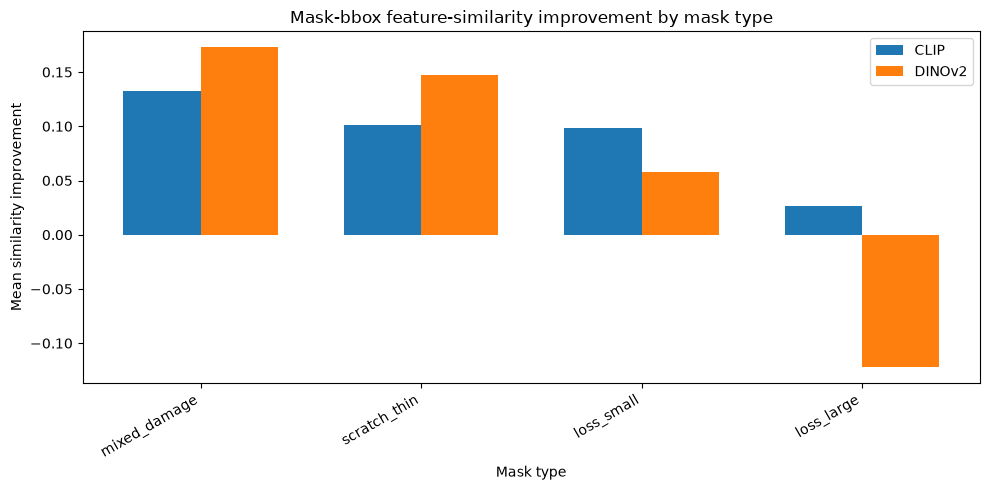

In [18]:
# Quick diagnostic plot: mask-bbox feature improvement by mask type

plot_df = mask_bbox_summary_df.sort_values(
    "mean_dinov2_similarity_improvement",
    ascending=False,
).copy()

x = np.arange(len(plot_df))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))

ax.bar(
    x - width / 2,
    plot_df["mean_clip_similarity_improvement"],
    width,
    label="CLIP",
)

ax.bar(
    x + width / 2,
    plot_df["mean_dinov2_similarity_improvement"],
    width,
    label="DINOv2",
)

ax.set_title("Mask-bbox feature-similarity improvement by mask type")
ax.set_xlabel("Mask type")
ax.set_ylabel("Mean similarity improvement")
ax.set_xticks(x)
ax.set_xticklabels(plot_df["mask_type"], rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

,category,cases,mean_clip_similarity_improvement,mean_dinov2_similarity_improvement
2,high_texture_brushwork,40,0.09135,0.09313
3,landscape_natural,40,0.09035,0.08718
4,portrait_figure,40,0.09020,0.07941
1,architecture_structured,40,0.11136,0.03398
0,abstraction_surrealism,40,0.06509,0.02661


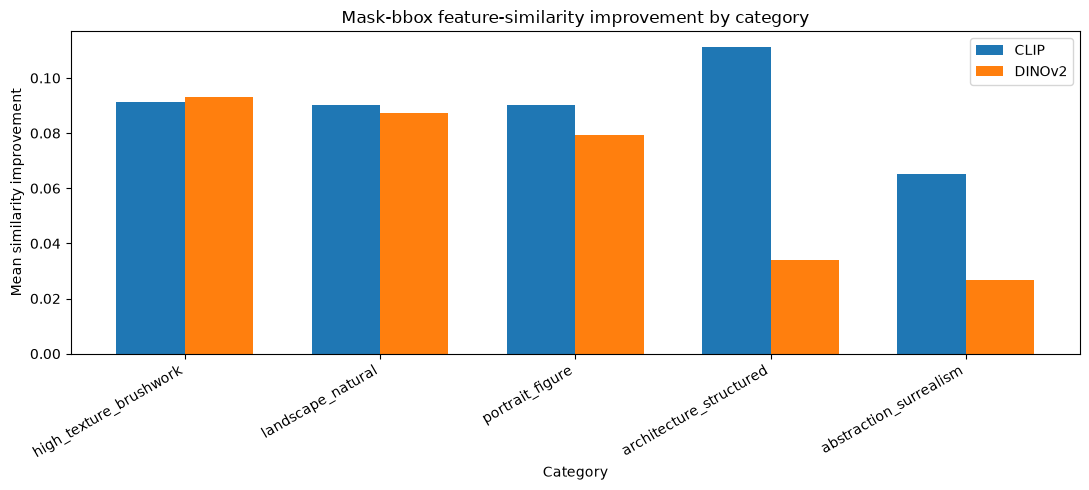

In [19]:
# Quick diagnostic plot: mask-bbox feature improvement by category

category_mask_bbox_summary_df = (
    feature_metrics_df[
        (feature_metrics_df["evaluation_region"] == "mask_bbox_crop")
        & (feature_metrics_df["status"] == "ok")
    ]
    .groupby("category")
    .agg(
        cases=("case_id", "count"),
        mean_clip_similarity_improvement=("clip_similarity_improvement", "mean"),
        mean_dinov2_similarity_improvement=("dinov2_similarity_improvement", "mean"),
    )
    .round(5)
    .reset_index()
    .sort_values("mean_dinov2_similarity_improvement", ascending=False)
)

display(category_mask_bbox_summary_df)

x = np.arange(len(category_mask_bbox_summary_df))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

ax.bar(
    x - width / 2,
    category_mask_bbox_summary_df["mean_clip_similarity_improvement"],
    width,
    label="CLIP",
)

ax.bar(
    x + width / 2,
    category_mask_bbox_summary_df["mean_dinov2_similarity_improvement"],
    width,
    label="DINOv2",
)

ax.set_title("Mask-bbox feature-similarity improvement by category")
ax.set_xlabel("Category")
ax.set_ylabel("Mean similarity improvement")
ax.set_xticks(x)
ax.set_xticklabels(category_mask_bbox_summary_df["category"], rotation=30, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

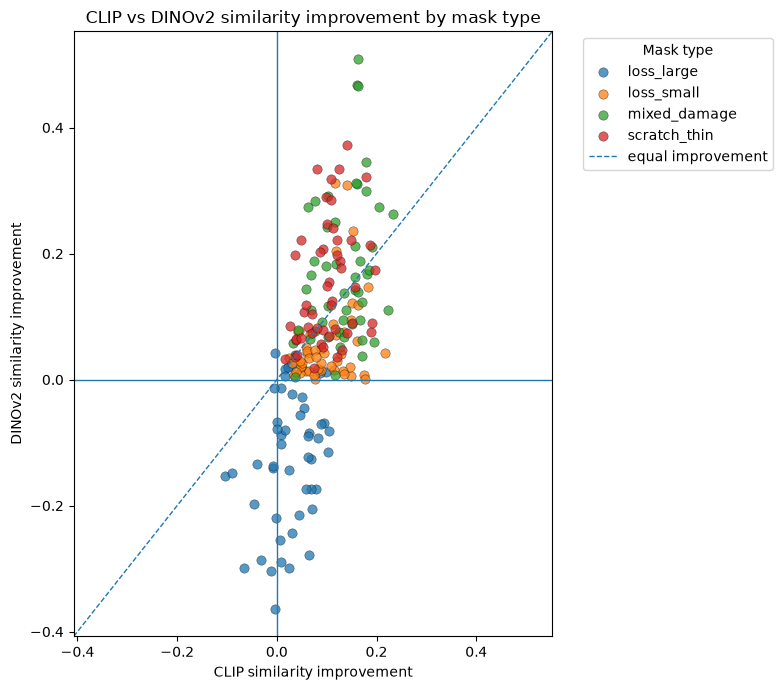

In [21]:
# Diagnostic plot: CLIP vs DINOv2 similarity improvement by mask type

scatter_df = feature_metrics_df[
    (feature_metrics_df["evaluation_region"] == "mask_bbox_crop")
    & (feature_metrics_df["status"] == "ok")
].copy()

fig, ax = plt.subplots(figsize=(8, 7))

mask_types = sorted(scatter_df["mask_type"].unique())

for mask_type in mask_types:
    subset_df = scatter_df[scatter_df["mask_type"] == mask_type]

    ax.scatter(
        subset_df["clip_similarity_improvement"],
        subset_df["dinov2_similarity_improvement"],
        alpha=0.75,
        label=mask_type,
        s=45,
        edgecolors="black",
        linewidths=0.3,
    )

# Reference lines
min_value = min(
    scatter_df["clip_similarity_improvement"].min(),
    scatter_df["dinov2_similarity_improvement"].min(),
)

max_value = max(
    scatter_df["clip_similarity_improvement"].max(),
    scatter_df["dinov2_similarity_improvement"].max(),
)

padding = (max_value - min_value) * 0.05

axis_min = min_value - padding
axis_max = max_value + padding

ax.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    linewidth=1,
    label="equal improvement",
)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlim(axis_min, axis_max)
ax.set_ylim(axis_min, axis_max)

ax.set_title("CLIP vs DINOv2 similarity improvement by mask type")
ax.set_xlabel("CLIP similarity improvement")
ax.set_ylabel("DINOv2 similarity improvement")

ax.legend(
    title="Mask type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

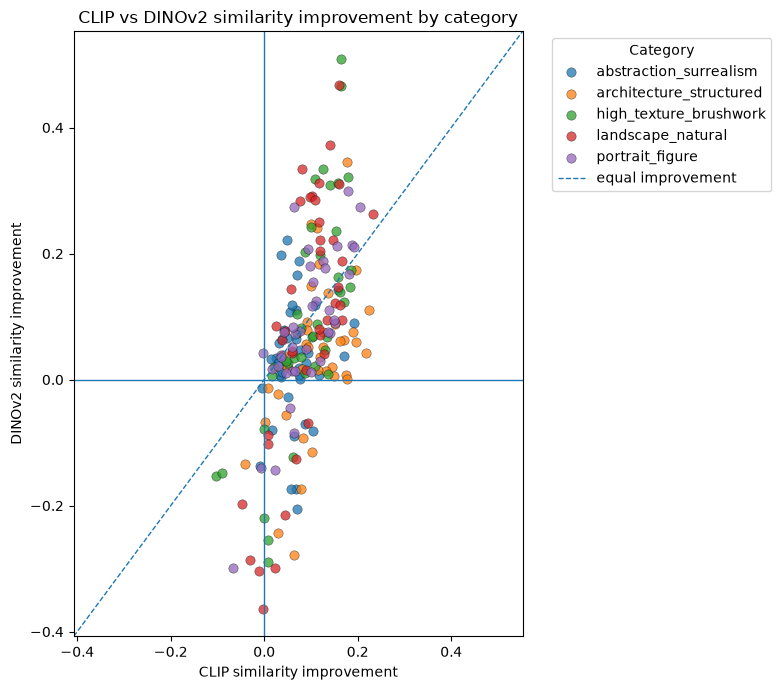

In [22]:
# Diagnostic plot: CLIP vs DINOv2 similarity improvement by category

scatter_df = feature_metrics_df[
    (feature_metrics_df["evaluation_region"] == "mask_bbox_crop")
    & (feature_metrics_df["status"] == "ok")
].copy()

fig, ax = plt.subplots(figsize=(8, 7))

categories = sorted(scatter_df["category"].unique())

for category in categories:
    subset_df = scatter_df[scatter_df["category"] == category]

    ax.scatter(
        subset_df["clip_similarity_improvement"],
        subset_df["dinov2_similarity_improvement"],
        alpha=0.75,
        label=category,
        s=45,
        edgecolors="black",
        linewidths=0.3,
    )

min_value = min(
    scatter_df["clip_similarity_improvement"].min(),
    scatter_df["dinov2_similarity_improvement"].min(),
)

max_value = max(
    scatter_df["clip_similarity_improvement"].max(),
    scatter_df["dinov2_similarity_improvement"].max(),
)

padding = (max_value - min_value) * 0.05

axis_min = min_value - padding
axis_max = max_value + padding

ax.plot(
    [axis_min, axis_max],
    [axis_min, axis_max],
    linestyle="--",
    linewidth=1,
    label="equal improvement",
)

ax.axhline(0, linewidth=1)
ax.axvline(0, linewidth=1)

ax.set_xlim(axis_min, axis_max)
ax.set_ylim(axis_min, axis_max)

ax.set_title("CLIP vs DINOv2 similarity improvement by category")
ax.set_xlabel("CLIP similarity improvement")
ax.set_ylabel("DINOv2 similarity improvement")

ax.legend(
    title="Category",
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
)

plt.tight_layout()
plt.show()

## Feature-space similarity result

CLIP and DINOv2 feature-space similarities were computed for the OpenCV Telea baseline on the 50-painting controlled subset.

The evaluation compared:

- clean image vs damaged image,
- clean image vs OpenCV-restored image.

Feature similarities were computed on image-like spatial regions:

- full image,
- painting content region,
- mask bounding-box crop.

Sparse masked pixels were not used directly because CLIP and DINOv2 expect spatial image inputs and produce embeddings from structured image regions.

Summary:

- 700 feature-similarity rows were generated,
- CLIP and DINOv2 cosine similarities were computed for damaged and restored images,
- zero-control cases produced no meaningful feature-similarity change,
- summary tables were saved by region, mask type, category, region-mask type, and region-category,
- strongest and weakest CLIP/DINOv2 improvement cases were exported,
- feature metrics were compared against classical metrics and LPIPS,
- metric-disagreement cases were exported for later qualitative inspection.

The feature-space results provide another diagnostic layer beyond classical pixel metrics and LPIPS. CLIP and DINOv2 measure similarity in different pretrained representation spaces, so they should not be treated as interchangeable or as final restoration-quality truth. Instead, they help identify whether restored outputs move closer to the clean reference in semantic or visual feature space.

The mask-bounding-box crop results show that feature-space improvement depends strongly on damage type. Scratch, small-loss, and mixed-damage cases generally show positive CLIP and DINOv2 improvement after OpenCV restoration. Large-loss cases behave differently. CLIP shows only weak average improvement for large losses, while DINOv2 shows negative average improvement for large-loss crops. This suggests that OpenCV's large-region interpolation can reduce obvious white damage while still producing local structures that are not close to the clean reference in DINOv2 feature space.

This does not mean that the white-damaged image is visually preferable. Rather, it shows that a local interpolation method can replace a missing region with content that is less aligned with the original visual structure according to a pretrained visual representation model. This is a useful diagnostic failure mode for the OpenCV baseline.

The comparison with MSE and LPIPS is especially important. MSE improvement correlates only weakly with CLIP and DINOv2 feature improvement, while LPIPS has a moderate relationship with both feature metrics. This confirms that classical pixel metrics, perceptual metrics, and pretrained feature-space metrics capture related but different aspects of restoration behavior.

Cases where classical, LPIPS, CLIP, and DINOv2 rankings diverge show that restoration quality cannot be reduced to a single scalar metric. This supports the project’s broader evaluation-framework argument: trustworthy assessment of AI-assisted painting restoration requires complementary metrics, visual diagnostics, and category-aware interpretation.